In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
# ==============================================================================
# CELL 0: INSTALLATIONS (Run this first, then Restart Session)
# ==============================================================================
!pip install -q faiss-cpu
!pip install -q ultralytics
!pip install -q insightface
!pip install -q onnxruntime-gpu
!pip install -q git+https://github.com/KaiyangZhou/deep-person-reid.git
!pip install -q ipywidgets

print("✅ Installations complete! Please RESTART YOUR SESSION now.")

  Preparing metadata (setup.py) ... done
✅ Installations complete! Please RESTART YOUR SESSION now.


In [5]:
# ==============================================================================
# 0. IMPORTS & SETUP (CLEAN CONSOLE)
# ==============================================================================
import os, cv2, torch, faiss, shutil, warnings, sys, pickle, logging
import os, cv2, torch, faiss, shutil, warnings, sys, pickle, logging

# 🤫 SILENCE THE VERBOSE AI LOGS
os.environ['ORT_LOGGING_LEVEL'] = '3'         
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'      
logging.getLogger('insightface').setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torchreid
from collections import defaultdict
from ultralytics import YOLO
from insightface.app import FaceAnalysis
from sklearn.cluster import KMeans

# 🚀 THE CRITICAL FIX FOR THE PROGRESS BAR
from tqdm.notebook import tqdm
# ==============================================================================
# 1. GLOBAL CONFIGURATION & AUTO-QUERY
# ==============================================================================
VIDEO_FOLDER = "/kaggle/input/datasets/aryashah2k/large-scale-multicamera-detection-dataset/Wildtrack" 
QUERY_IMAGE = "/kaggle/working/auto_query.jpg" 
BASE_OUTPUT_DIR = "/kaggle/working/forensic_master"

if os.path.exists(BASE_OUTPUT_DIR): shutil.rmtree(BASE_OUTPUT_DIR)
os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MIN_WIDTH, MIN_HEIGHT = 50, 100    
BLUR_THRESHOLD = 80.0              

# --- AUTO-QUERY EXTRACTOR ---
if not os.path.exists(QUERY_IMAGE):
    print("🤖 No query image found. Auto-extracting a suspect from cam1.mp4...")
    temp_yolo = YOLO("yolov8m.pt")
    cap = cv2.VideoCapture(os.path.join(VIDEO_FOLDER, "cam1.mp4"))
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        res = temp_yolo.track(frame, persist=True, verbose=False)
        if res[0].boxes is not None and res[0].boxes.id is not None:
            for box in res[0].boxes.xyxy.cpu().numpy():
                x1, y1, x2, y2 = map(int, box)
                if (x2-x1) > 80 and (y2-y1) > 160: 
                    cv2.imwrite(QUERY_IMAGE, frame[max(0,y1):y2, max(0,x1):x2])
                    print(f"✅ Target acquired! Saved as: {QUERY_IMAGE}")
                    break
        if os.path.exists(QUERY_IMAGE): break
    cap.release()

# ==============================================================================
# 2. MODEL INITIALIZATION (SILENT MODE)
# ==============================================================================
print(f"\n📦 Loading 18-Stage AI Pipeline on {DEVICE.upper()}...")
yolo = YOLO("yolov8m-seg.pt")
osnet_model = torchreid.models.build_model(name="osnet_x1_0", num_classes=1000, pretrained=True).to(DEVICE).eval()

import contextlib
with contextlib.redirect_stdout(open(os.devnull, 'w')):
    face_app = FaceAnalysis(allowed_modules=['detection', 'recognition'])
    face_app.prepare(ctx_id=0 if DEVICE == "cuda" else -1, det_size=(640, 640))

# ==============================================================================
# 3. HELPER FUNCTIONS
# ==============================================================================
def format_time(f_num, fps):
    sec = int(f_num / max(1, fps))
    return f"{sec//3600:02d}:{(sec%3600)//60:02d}:{sec%60:02d}"

def get_body_emb(img_bgr):
    img = cv2.resize(img_bgr, (128, 256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img = (img - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
    tensor = torch.tensor(np.transpose(img, (2, 0, 1)), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): feat = osnet_model(tensor).cpu().numpy().flatten()
    return feat / (np.linalg.norm(feat) + 1e-12)

def get_face_emb(img_bgr):
    faces = face_app.get(img_bgr)
    if not faces: return None, 0, 0.0
    face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0]) * (f.bbox[3]-f.bbox[1]))
    return face.embedding, (face.bbox[2]-face.bbox[0])*(face.bbox[3]-face.bbox[1]), face.det_score

def fuse_embs(body_emb, face_emb, f_area, b_area, f_conf):
    if face_emb is None or (f_area/max(1, b_area)) < 0.05 or f_conf < 0.85:
        return np.concatenate([np.zeros(512), body_emb])
    alpha = 0.6 if (f_area / max(1, b_area)) >= 0.15 else 0.3
    fused = np.concatenate([alpha * face_emb, (1.0 - alpha) * body_emb])
    return fused / (np.linalg.norm(fused) + 1e-12)

# ==============================================================================
# ENGINE 1: INGESTION 
# ==============================================================================
print("\n🏗️ ENGINE 1: Indexing Wildtrack cameras...")
global_metadata, gallery_protos, proto_to_gid = defaultdict(list), [], []
video_files = sorted([f for f in os.listdir(VIDEO_FOLDER) if f.endswith('.mp4')])

for v_name in tqdm(video_files, desc="🎥 Total Video Progress"):
    v_path = os.path.join(VIDEO_FOLDER, v_name)
    cap = cv2.VideoCapture(v_path)
    total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    f_idx, track_dict = 0, defaultdict(list)
    
    pbar = tqdm(total=total_f, desc=f"   ↳ Scanning {v_name}", leave=False)
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        if f_idx % max(1, int(fps)) == 0:
            res = yolo.track(frame, persist=True, tracker="botsort.yaml", verbose=False)
            if res[0].boxes is not None and res[0].boxes.id is not None:
                boxes, ids, masks = res[0].boxes.xyxy.cpu().numpy(), res[0].boxes.id.cpu().numpy(), res[0].masks
                for i, box in enumerate(boxes):
                    x1, y1, x2, y2 = map(int, box)
                    if (x2-x1) < MIN_WIDTH or (y2-y1) < MIN_HEIGHT: continue
                    
                    crop = frame[max(0,y1):y2, max(0,x1):x2].copy()
                    if masks is not None and len(masks.xy) > i and len(masks.xy[i]) > 0:
                        poly = masks.xy[i].copy().astype(np.int32)
                        poly[:, 0] -= max(0, x1); poly[:, 1] -= max(0, y1)
                        mask_canvas = np.zeros(crop.shape[:2], dtype=np.uint8)
                        cv2.fillPoly(mask_canvas, [poly], 1)
                        crop[mask_canvas == 0] = 0
                        
                    if cv2.Laplacian(cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY), cv2.CV_64F).var() < BLUR_THRESHOLD: continue
                    
                    b_emb = get_body_emb(crop)
                    f_emb, f_area, f_conf = get_face_emb(crop)
                    fused = fuse_embs(b_emb, f_emb, f_area, crop.shape[0]*crop.shape[1], f_conf)
                    
                    tid = int(ids[i])
                    g_id = f"{v_name}_ID_{tid}"
                    track_dict[tid].append(fused)
                    global_metadata[g_id].append({'v_path': v_path, 'fps': fps, 'f': f_idx, 't': f_idx/fps, 'b': (x1,y1,x2,y2), 'e': fused})
        f_idx += 1
        pbar.update(1)
    pbar.close(); cap.release()

    for tid, embs in track_dict.items():
        arr = np.vstack(embs)
        clean_embs = arr[np.linalg.norm(arr - np.mean(arr, axis=0), axis=1) < (np.mean(np.linalg.norm(arr - np.mean(arr, axis=0), axis=1)) + 2*np.std(np.linalg.norm(arr - np.mean(arr, axis=0), axis=1)))] if len(arr) > 2 else arr
        if len(clean_embs) == 0: continue
        km = KMeans(n_clusters=max(1, min(5, len(clean_embs))), random_state=42, n_init=10).fit(clean_embs)
        for center in km.cluster_centers_:
            gallery_protos.append(center / (np.linalg.norm(center) + 1e-12))
            proto_to_gid.append(f"{v_name}_ID_{tid}")

if len(gallery_protos) == 0:
    print("❌ CRITICAL: No suspects indexed. Try lowering MIN_WIDTH/HEIGHT.")
    sys.exit()

# 💾 SAVE DATA CHECKPOINT
print("\n💾 SAVING ENGINE 1 PROGRESS...")
with open('/kaggle/working/global_metadata.pkl', 'wb') as f: pickle.dump(global_metadata, f)
with open('/kaggle/working/gallery_protos.pkl', 'wb') as f: pickle.dump(gallery_protos, f)
with open('/kaggle/working/proto_to_gid.pkl', 'wb') as f: pickle.dump(proto_to_gid, f)
print("✅ Progress safely locked in! You can now move to Cell 2.")


📦 Loading 18-Stage AI Pipeline on CUDA...
Successfully loaded imagenet pretrained weights from "/root/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth"

🏗️ ENGINE 1: Indexing Wildtrack cameras...


🎥 Total Video Progress:   0%|          | 0/7 [00:00<?, ?it/s]

   ↳ Scanning cam1.mp4:   0%|          | 0/125874 [00:00<?, ?it/s]

   ↳ Scanning cam2.mp4:   0%|          | 0/125874 [00:00<?, ?it/s]

   ↳ Scanning cam3.mp4:   0%|          | 0/125873 [00:00<?, ?it/s]

   ↳ Scanning cam4.mp4:   0%|          | 0/125874 [00:00<?, ?it/s]

   ↳ Scanning cam5.mp4:   0%|          | 0/125874 [00:00<?, ?it/s]

   ↳ Scanning cam6.mp4:   0%|          | 0/125874 [00:00<?, ?it/s]

   ↳ Scanning cam7.mp4:   0%|          | 0/125874 [00:00<?, ?it/s]


💾 SAVING ENGINE 1 PROGRESS...
✅ Progress safely locked in! You can now move to Cell 2.


🔄 LOADING SAVED PROGRESS...
✅ Data Loaded! Bypassing Engine 1.

🔍 ENGINE 2: Processing Query & Generating Grid...


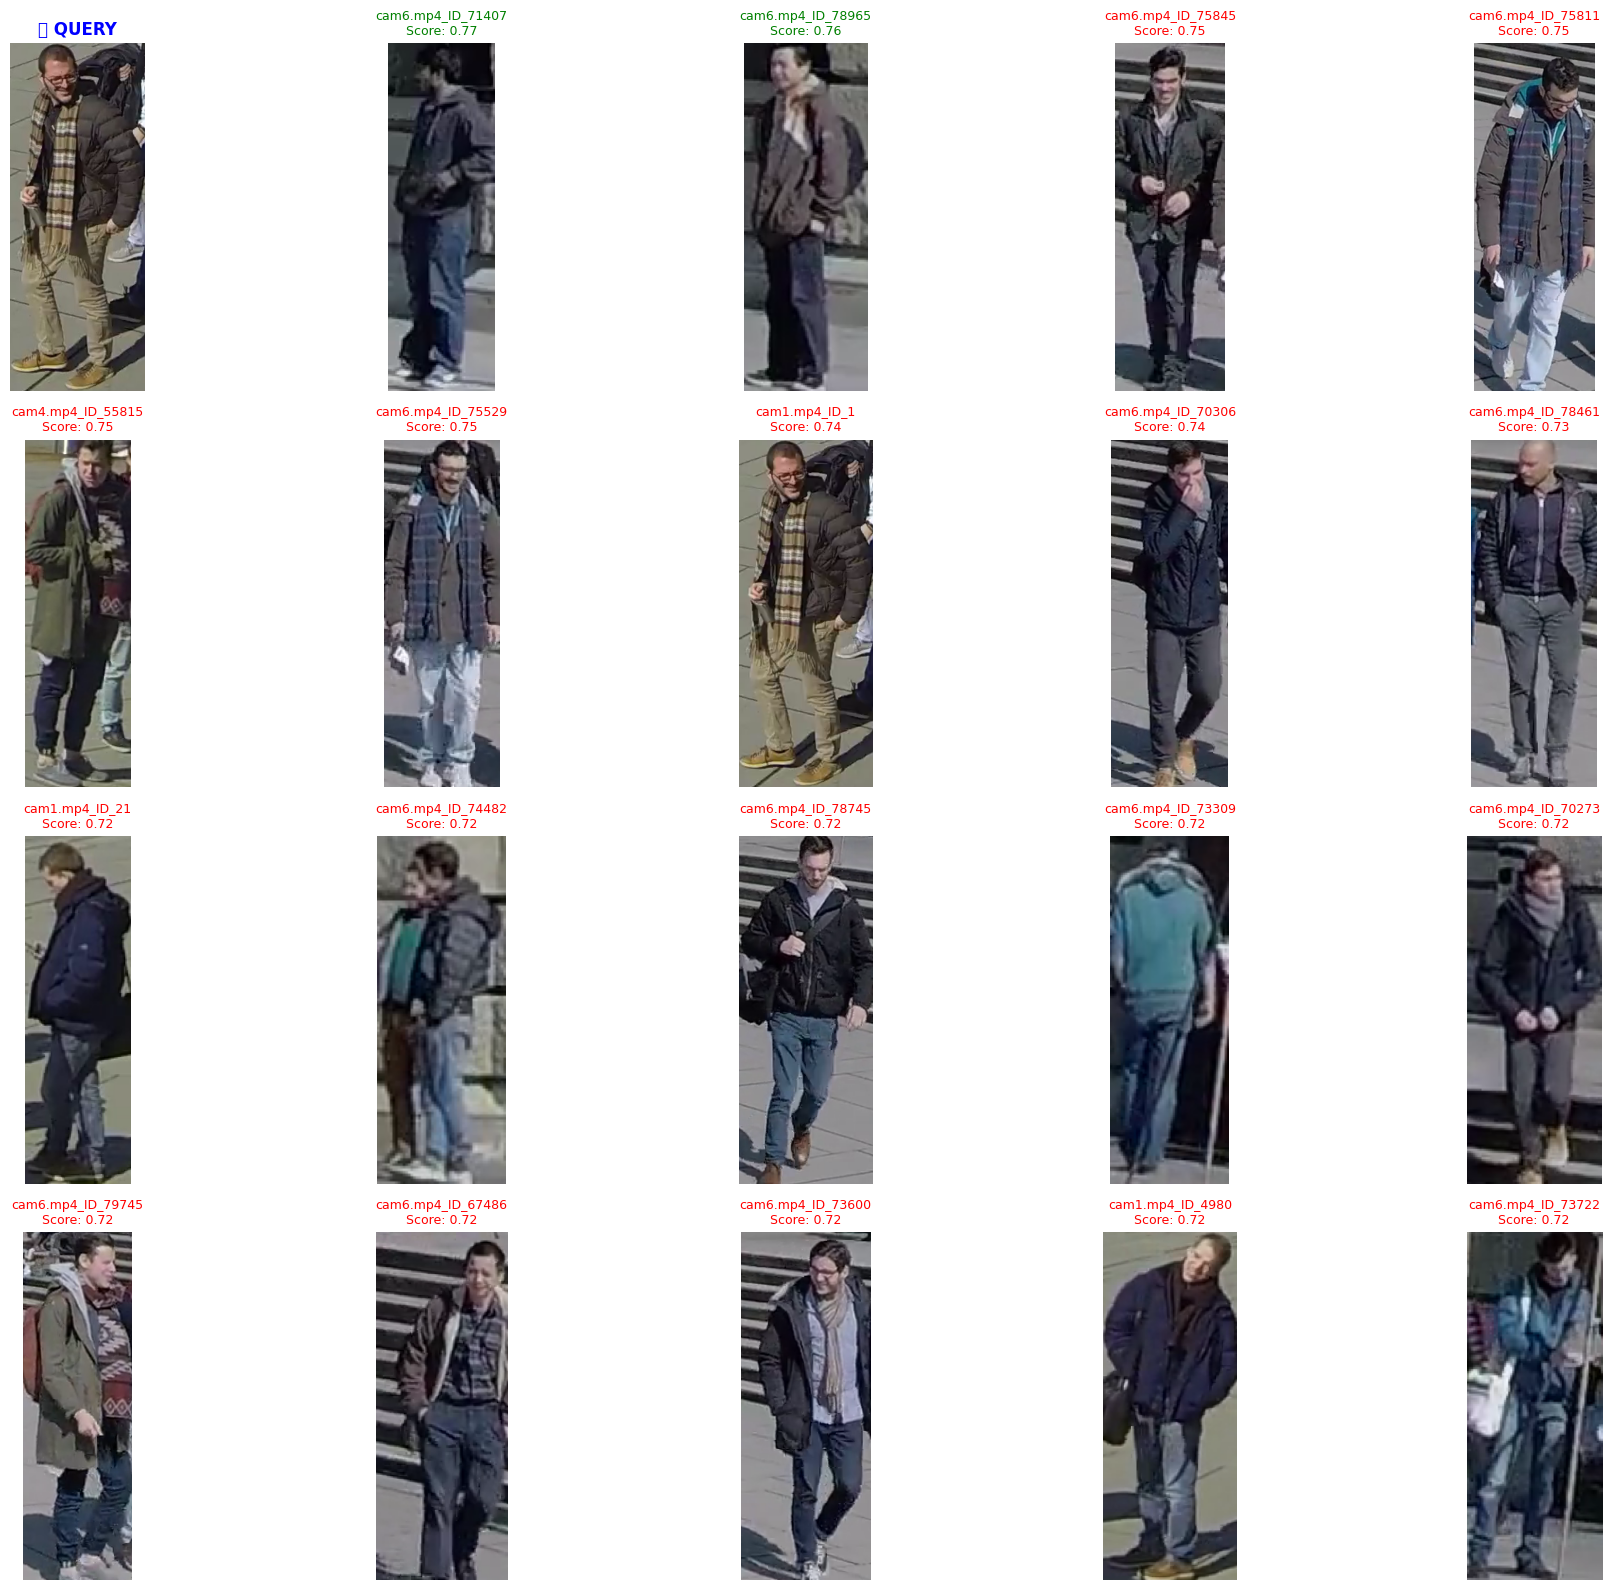

🎯 Enter Global IDs (comma separated):  cam1.mp4_ID_1,cam6.mp4_ID_78745


🎬 Rendering Evidence:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Saved: /kaggle/working/forensic_master/evidence_cam1_ID_1.avi
✅ Saved: /kaggle/working/forensic_master/evidence_cam6_ID_78745.avi


In [6]:
# ==============================================================================
# 0. LOAD SAVED DATA (Bypassing Engine 1)
# ==============================================================================
import pickle, faiss, cv2, os, sys
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

print("🔄 LOADING SAVED PROGRESS...")
try:
    with open('/kaggle/working/global_metadata.pkl', 'rb') as f: global_metadata = pickle.load(f)
    with open('/kaggle/working/gallery_protos.pkl', 'rb') as f: gallery_protos = pickle.load(f)
    with open('/kaggle/working/proto_to_gid.pkl', 'rb') as f: proto_to_gid = pickle.load(f)
    print("✅ Data Loaded! Bypassing Engine 1.")
except FileNotFoundError:
    print("❌ CRITICAL ERROR: .pkl files not found. Ensure Engine 1 finished saving.")
    sys.exit()

# ==============================================================================
# 1. ENGINE 2: SEARCH & HITL GRID
# ==============================================================================
print("\n🔍 ENGINE 2: Processing Query & Generating Grid...")
index = faiss.IndexFlatIP(1024)
index.add(np.vstack(gallery_protos).astype("float32"))

q_img = cv2.imread(QUERY_IMAGE)
if q_img is None:
    print(f"❌ ERROR: Query image not found at {QUERY_IMAGE}")
else:
    # Extract fingerprints from Query
    q_b_emb = get_body_emb(q_img)
    q_f_emb, q_f_area, q_f_conf = get_face_emb(q_img)
    q_b_area = q_img.shape[0] * q_img.shape[1]
    
    # Fuse Query Embeddings
    q_emb = fuse_embs(q_b_emb, q_f_emb, q_f_area, q_b_area, q_f_conf).reshape(1, -1)

    # Search & Re-rank
    sims, idxs = index.search(q_emb.astype("float32"), k=100)
    raw_scores, frequency = defaultdict(float), defaultdict(int)
    for i, p_idx in enumerate(idxs[0]):
        if p_idx == -1: continue
        g_id = proto_to_gid[p_idx]
        raw_scores[g_id] = max(raw_scores[g_id], sims[0][i])
        frequency[g_id] += 1
    
    re_ranked = {g_id: min(1.0, score * (1.0 + (min(frequency[g_id], 5) * 0.02))) 
                 for g_id, score in raw_scores.items()} 

    # Plotting the Grid
    display_ids = sorted(re_ranked, key=re_ranked.get, reverse=True)[:19]
    cols, rows = 5, (len(display_ids) + 2) // 5
    fig, axes = plt.subplots(max(2, rows), cols, figsize=(20, 4 * rows))
    axes_flat = axes.flatten()
    
    axes_flat[0].imshow(cv2.cvtColor(q_img, cv2.COLOR_BGR2RGB))
    axes_flat[0].set_title("🎯 QUERY", color='blue', fontweight='bold'); axes_flat[0].axis('off')

    for i, g_id in enumerate(display_ids):
        idx = i + 1
        best = max(global_metadata[g_id], key=lambda x: np.dot(q_emb, x['e'])[0])
        cap = cv2.VideoCapture(best['v_path'])
        cap.set(cv2.CAP_PROP_POS_FRAMES, best['f'])
        ret, f = cap.read()
        if ret:
            x1, y1, x2, y2 = best['b']
            crop = f[max(0,y1):y2, max(0,x1):x2]
            if crop.size > 0: # Guard against empty crops
                axes_flat[idx].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
                color = 'green' if re_ranked[g_id] > 0.75 else 'red'
                axes_flat[idx].set_title(f"{g_id}\nScore: {re_ranked[g_id]:.2f}", color=color, fontsize=9)
        axes_flat[idx].axis('off')
        cap.release()
    plt.tight_layout(); plt.show()

# ==============================================================================
# 2. ENGINE 3: FINAL EXTRACTION
# ==============================================================================
user_input = input(f"🎯 Enter Global IDs (comma separated): ")
target_ids = [x.strip() for x in user_input.split(",") if x.strip() in global_metadata]

if not target_ids:
    print("⚠️ No valid IDs selected. Run the cell again to enter IDs.")
else:
    for g_id in tqdm(target_ids, desc="🎬 Rendering Evidence"):
        meta = global_metadata[g_id]
        v_path, fps = meta[0]['v_path'], meta[0]['fps']
        t_start = max(0, min([m['t'] for m in meta]) - 1)
        t_end = max([m['t'] for m in meta]) + 1
        
        # Smooth tracking interpolation
        frame_map = {} 
        for i in range(len(meta)-1):
            frame_map[meta[i]['f']] = meta[i]
            gap = meta[i+1]['f'] - meta[i]['f']
            if 1 < gap < (int(fps) * 5): # Interpolate gaps up to 5 seconds
                for j in range(1, gap):
                    frac = j/gap
                    b, b2 = meta[i]['b'], meta[i+1]['b']
                    interp_box = (int(b[0]+(b2[0]-b[0])*frac), int(b[1]+(b2[1]-b[1])*frac), 
                                  int(b[2]+(b2[2]-b[2])*frac), int(b[3]+(b2[3]-b[3])*frac))
                    frame_map[meta[i]['f']+j] = {'b': interp_box, 'e': meta[i]['e'], 'smoothed': True}
        frame_map[meta[-1]['f']] = meta[-1]

        cap = cv2.VideoCapture(v_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(t_start * fps))
        
        # 🛡️ FAIL-SAFE: Using XVID .avi for Kaggle compatibility
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out_path = os.path.join(BASE_OUTPUT_DIR, f"evidence_{g_id.replace('.mp4','').replace('.','_')}.avi")
        out = cv2.VideoWriter(out_path, fourcc, fps, (int(cap.get(3)), int(cap.get(4))))
        
        for f_num in range(int(t_start * fps), int(t_end * fps)):
            ret, f = cap.read()
            if not ret: break
            if f_num in frame_map:
                d = frame_map[f_num]
                x1, y1, x2, y2 = d['b']
                # Orange = Interpolated, Red = AI Detected
                color = (0, 165, 255) if d.get('smoothed') else (0, 0, 255)
                cv2.rectangle(f, (x1, y1), (x2, y2), color, 3)
                cv2.putText(f, f"ID: {g_id} CONF:{np.dot(q_emb, d['e'])[0]:.2f}", (x1, y1-10), 0, 0.6, (0, 255, 255), 2)
            out.write(f)
        
        cap.release(); out.release()
        print(f"✅ Saved: {out_path}")